# CNC 밀링머신 진동데이터셋 — 전처리 및 이상탐지

**데이터셋**: CNC Machining Data (Kaggle, Maximilian Fellhuber)

- 3축 가속도계 (acc_x, acc_y, acc_z), **2 kHz** 샘플링
- 3대의 CNC 머신 (M01, M02, M03)
- 파일명 형식: `label_AB.csv` (A=머신번호, B=프로세스/상태)

### 학습 파이프라인

1. 데이터 로드 및 EDA
2. 윈도잉 & 다운샘플링
3. 정규화 (Min-Max)
4. 특징 추출 (시간 도메인 + 주파수 도메인)
5. 이상탐지 — Isolation Forest + Autoencoder
6. 결과 시각화

```{admonition} 학습 목표
:class: tip

- 진동 신호 처리의 전체 파이프라인을 이해합니다
- **시간/주파수 도메인 특징 추출**의 원리와 의미를 파악합니다
- 두 가지 이상탐지 접근법(특징 기반 vs 재구성 오차 기반)을 비교합니다
- Autoencoder가 **정상 데이터만 학습**하여 이상을 탐지하는 메커니즘을 이해합니다
```

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm import tqdm
from scipy import stats
from scipy.signal import welch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam


I0000 00:00:1780377720.130944 2463399 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780377720.191681 2463399 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1780377721.587751 2463399 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### 3. 실험 설정

가속도계의 원본 샘플링 주파수와 윈도우 길이, 다운샘플링 계수를 정의합니다.

- <span style="color:#2980B9">SAMPLE_RATE=2000</span>: 가속도계 원본 샘플링 주파수 (2 kHz)
- <span style="color:#2980B9">WINDOW_SEC=10</span>: 10초 단위로 데이터를 잘라 윈도우 생성
- <span style="color:#2980B9">DOWNSAMPLE_FACTOR=10</span>: 평균 풀링 다운샘플링 계수
- 하나의 윈도우 = 10초 × 2000Hz = <span style="color:#E74C3C; font-weight:bold">20,000개 샘플</span>

파일명 `label_AB.csv`에서 **A=머신번호, B=상태번호**를 의미합니다:

| 머신 | 파일 | 라벨 | 설명 |
|------|------|------|------|
| M01 | label_0X | 정상 | 정상 운전 데이터 |
| M02 | label_1X | 혼합 | 학습에 사용하지 않음 |
| M03 | label_2X | 이상 | 다양한 이상 패턴 포함 |


In [2]:
DATA_DIR = "/home/growingwithai/dev/205-research-etri/lecture/h1_data_copy/Dataset/Dataset"
SAMPLE_RATE = 2000
WINDOW_SEC = 10
DOWNSAMPLE_FACTOR = 10
WINDOW_SIZE = WINDOW_SEC * SAMPLE_RATE  # 20000 샘플/윈도우
RANDOM_STATE = 42

NORMAL_FILES = ["label_00", "label_01", "label_02"]
MIXED_FILES  = ["label_11", "label_12"]
ANOMALY_FILES = ["label_20", "label_21", "label_22",
                 "label_23", "label_24", "label_25", "label_26"]

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

### 4. 데이터 로드 — 윈도잉

연속 시계열을 고정 길이 윈도우로 분할합니다.

- <span style="color:#2980B9">WINDOW_SEC=10</span>: 10초 단위로 데이터를 자릅니다
- 하나의 윈도우 = 10초 × 2000Hz = <span style="color:#E74C3C; font-weight:bold">20,000개 샘플</span>
- <span style="color:#2980B9">max_windows</span>: 실험 속도를 위해 파일당 최대 윈도우 수를 제한합니다
- 최종 데이터 shape: <span style="color:#27AE60">(n_windows, 20000, 3)</span> — 윈도우 수 × 샘플 × 3축

```{admonition} 왜 비겹침(non-overlapping) 분할인가?
:class: tip

슬라이딩 윈도우가 아닌 비겹침 분할을 사용합니다.
윈도우 간 독립성을 보장하여 <strong>데이터 누수(data leakage)</strong>를 방지합니다.
또한 파일당 약 2.4M 행을 120개 윈도우로 분할하여 메모리 관리와 특징 추출을 용이하게 합니다.
```

In [3]:
def load_data(data_dir, files, max_windows=None):
    """CSV 파일들을 로드하여 윈도우 단위로 분할."""
    windows = []
    for fname in files:
        path = os.path.join(data_dir, f"{fname}.csv")
        if not os.path.exists(path):
            print(f"  [SKIP] {path} 없음")
            continue
        print(f"  로드 중: {fname}.csv")
        df = pd.read_csv(path)
        data_np = df.to_numpy()  # (N, 3)

        n_samples = data_np.shape[0]
        n_full_windows = n_samples // WINDOW_SIZE

        for i in range(n_full_windows):
            if max_windows and len(windows) >= max_windows:
                break
            start = i * WINDOW_SIZE
            end = start + WINDOW_SIZE
            windows.append(data_np[start:end])

    return np.array(windows)  # (n_windows, WINDOW_SIZE, 3)


normal_windows = load_data(DATA_DIR, NORMAL_FILES, max_windows=100)
mixed_windows  = load_data(DATA_DIR, MIXED_FILES,  max_windows=50)
anomaly_windows = load_data(DATA_DIR, ANOMALY_FILES, max_windows=100)

print(f"정상 윈도우:   {normal_windows.shape}")
print(f"혼합 윈도우:   {mixed_windows.shape}")
print(f"이상 윈도우:   {anomaly_windows.shape}")


  로드 중: label_00.csv
  로드 중: label_01.csv
  로드 중: label_02.csv
  로드 중: label_11.csv
  로드 중: label_12.csv


  로드 중: label_20.csv
  로드 중: label_21.csv


  로드 중: label_22.csv
  로드 중: label_23.csv


  로드 중: label_24.csv
  로드 중: label_25.csv
  로드 중: label_26.csv


정상 윈도우:   (17, 20000, 3)
혼합 윈도우:   (15, 20000, 3)
이상 윈도우:   (100, 20000, 3)


### 5. EDA — 탐색적 데이터 분석

원시 진동 데이터를 시각화하여 정상과 이상 패턴의 차이를 직관적으로 파악합니다.

- **원시 파형 비교**: 첫 0.1초(200포인트) 구간에서 정상(M01)과 이상(M03)의 진동 형태를 비교합니다
- **KDE(커널 밀도 추정) 플롯**: 두 분포가 얼마나 겹치는지 확인합니다. 분포가 분리되어 있을수록 이상탐지가 용이합니다
- <span style="color:#2980B9">[::100]</span>: 메모리 절약을 위해 100개 간격으로 서브샘플링합니다


/tmp/ipykernel_2463399/3523945728.py:16: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/3523945728.py:16: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/3523945728.py:16: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/3523945728.py:16: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/3523945728.py:16: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/3523945728.py:16: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/3523945728.py:16: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu S

/home/growingwithai/dev/205-research-etri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/growingwithai/dev/205-research-etri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/growingwithai/dev/205-research-etri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/growingwithai/dev/205-research-etri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/growingwithai/dev/205-research-etri/.venv/lib/pytho

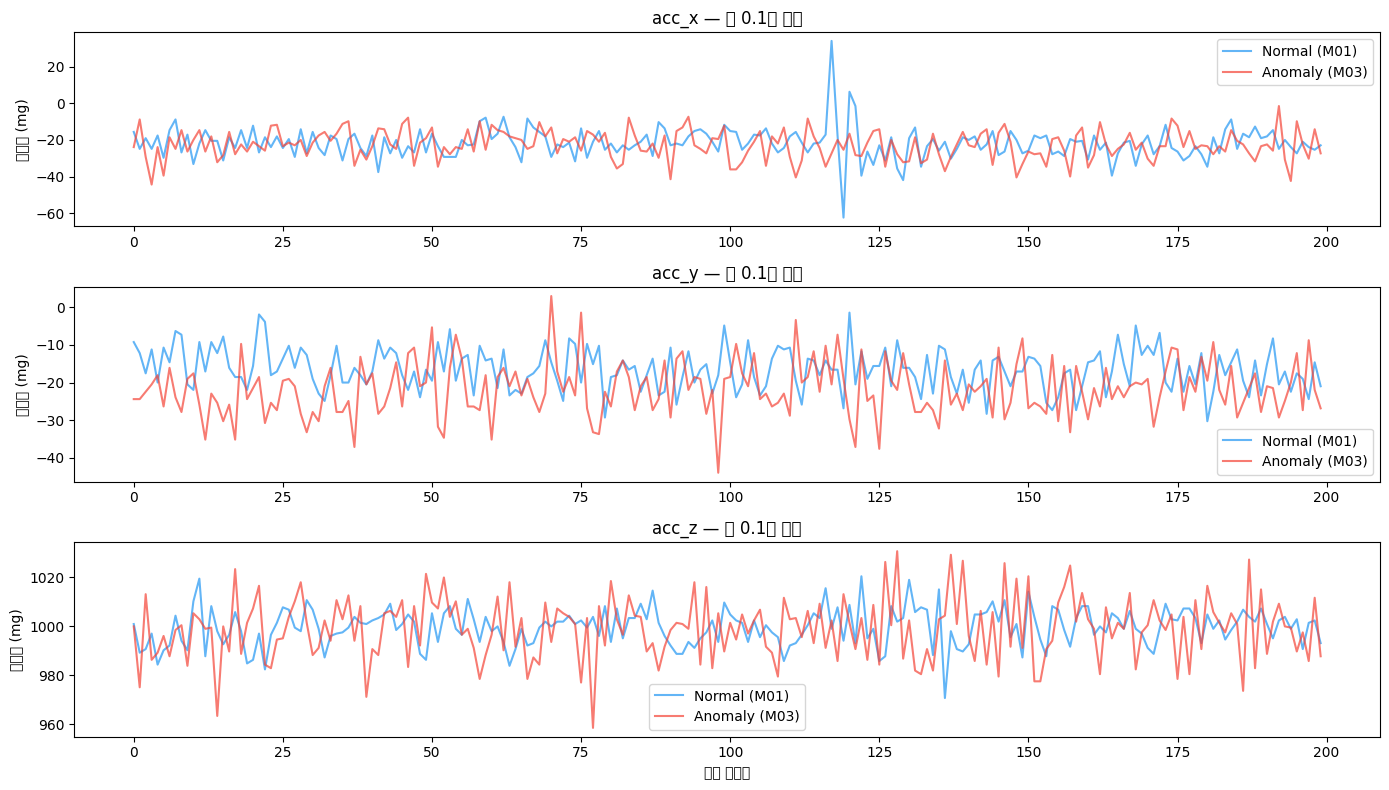

/tmp/ipykernel_2463399/3523945728.py:29: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/3523945728.py:29: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/3523945728.py:30: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{SAVE_DIR}/h1_eda_distribution.png", dpi=150)
/tmp/ipykernel_2463399/3523945728.py:30: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{SAVE_DIR}/h1_eda_distribution.png", dpi=150)


/home/growingwithai/dev/205-research-etri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/growingwithai/dev/205-research-etri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


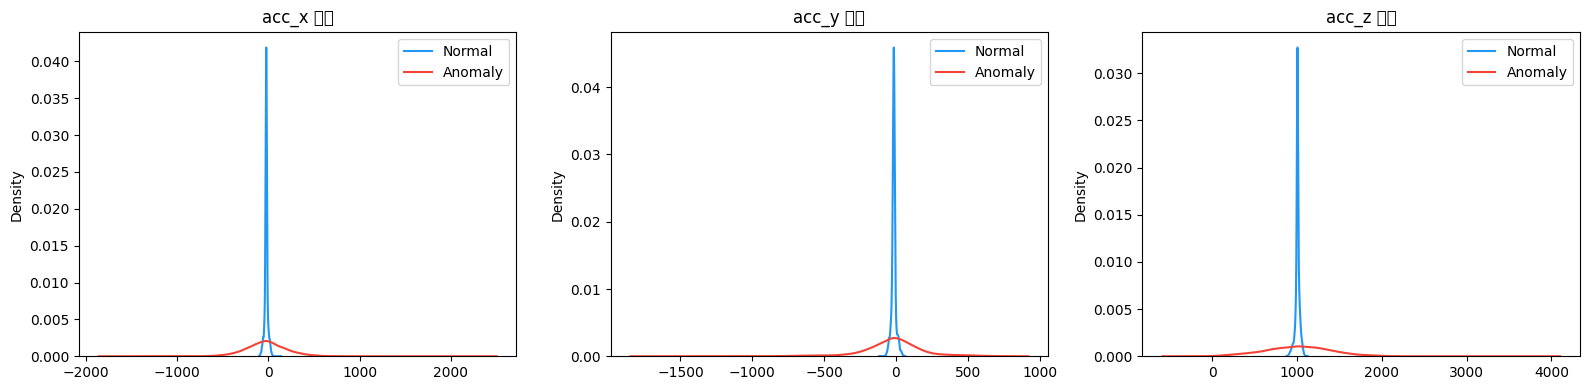

In [4]:
SAVE_DIR = "/home/growingwithai/dev/205-research-etri/lecture"

axis_names = ["acc_x", "acc_y", "acc_z"]
colors = ["#2196F3", "#4CAF50", "#F44336"]

# 원시 파형 비교
fig, axes = plt.subplots(3, 1, figsize=(14, 8))
for i, ax in enumerate(axes):
    ax.plot(normal_windows[0, :200, i], color=colors[0], alpha=0.7, label="Normal (M01)")
    ax.plot(anomaly_windows[0, :200, i], color=colors[2], alpha=0.7, label="Anomaly (M03)")
    ax.set_title(f"{axis_names[i]} — 첫 0.1초 비교")
    ax.set_ylabel("가속도 (mg)")
    ax.legend()

axes[-1].set_xlabel("샘플 인덱스")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/h1_eda_raw.png", dpi=150)
plt.show()

# KDE 분포 비교
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, ax in enumerate(axes):
    normal_flat = normal_windows[:, :, i].flatten()
    anomaly_flat = anomaly_windows[:, :, i].flatten()
    sns.kdeplot(normal_flat[::100], ax=ax, label="Normal", color="#2196F3")
    sns.kdeplot(anomaly_flat[::100], ax=ax, label="Anomaly", color="#F44336")
    ax.set_title(f"{axis_names[i]} 분포")
    ax.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/h1_eda_distribution.png", dpi=150)
plt.show()

#### EDA 결과 해석 — 핵심 발견

원시 데이터(라벨 `00`~`26`, 총 2,994,307행, 결측치 0)에 대한 탐색적 분석 결과입니다.

**1) 평균은 조건과 무관하게 거의 동일**
- x̄ ≈ -25, ȳ ≈ -17, z̄ ≈ 1,005 mg (z축에 중력 ≈ 1g 오프셋)
- → 센서 거치 자세는 조건 간 동일. **분류 단서는 평균이 아니라 변동성(σ)·동역학**에 있습니다.

**2) 변동성(σ·RMS)의 조건 분별력**

| 조건 (파일) | acc_x σ | acc_x RMS |
|---|---:|---:|
| 정상 (00–02) | 약 6–26 | 28.6 |
| 이상·마모 (20–26) | 약 137–292 | 220.1 |
| 혼합·채터링 (11–12) | 약 349–373 | 363.0 |

- 정상 대비 마모 약 50배, 채터링 약 63배 → σ·RMS 룰만으로도 상위 구분이 거의 가능합니다.

**3) 단순 통계가 놓치는 라벨별 패턴**
- **라벨 01(정상)의 숨은 스파이크**: σ는 작지만 acc_x 첨도 ≈ 2,900, 최소 -1,299 mg — 평소 정지 + 드문 강한 충격. → `kurtosis` 특징이 이를 포착합니다(섹션 7과 연결).
- **라벨 11(채터링)의 축 결합**: 축 간 상관 |r| 0.59~0.64 — 단순 진폭 증가가 아니라 축들의 위상이 묶여 함께 떨립니다.
- **magnitude √(x²+y²+z²) 범위**: 고동역 조건은 약 10 ~ 5,000 mg → 자유낙하(≈0)부터 4~5 g 충격까지 포함합니다.

**4) 데이터 품질**
- **라벨 00의 49% 중복 행**은 정지 상태에서 동일 (x,y,z) 튜플이 자연 발생한 것 → 이상치가 아니므로 제거 금지.
- 원시 클래스 분포는 마모(2x) 77.9%, 정상(0x) 12.0%, 채터링(1x) 10.1%로 **이상이 다수**인 불균형입니다.

**5) 주파수 — 정규화 주파수 기준 (참고)**
- 원시 CSV에는 타임스탬프·샘플링 주파수가 없어, 위 셀의 `SAMPLE_RATE=2000`은 **가정값**입니다.
- fs와 무관한 정규화 주파수(cycles/sample, Nyquist=0.5)로 본 지배 성분: 정상 ≈ 0.08–0.11(저주파), 채터링 ≈ 0.40(고주파, 나이퀴스트의 약 80%), 마모 0.14–0.46(넓은 대역).
- 절대 Hz는 가정한 fs에 따라 `Hz = 정규화주파수 × fs`로 환산되므로, fs가 확정되기 전에는 정규화 주파수로 해석하는 것이 안전합니다.


### 6. 전처리 — 다운샘플링

원본 20,000포인트를 그대로 사용하면 특징 추출과 모델 학습에 과도한 연산이 필요합니다.

- <span style="color:#2980B9">DOWNSAMPLE_FACTOR=10</span>: 10개씩 묶어 평균을 취합니다
- <span style="color:#27AE60">20,000 → 2,000 포인트</span>로 축소 (데이터 양 1/10)
- 단순 간격 샘플링이 아닌 <span style="color:#E74C3C; font-weight:bold">평균 풀링(average pooling)</span>을 사용하여 정보 손실을 최소화합니다


In [5]:
def downsample(data, factor):
    """윈도우 데이터를 factor만큼 다운샘플링 (평균 풀링)."""
    n_windows = data.shape[0]
    new_len = data.shape[1] // factor
    n_axes = data.shape[2]
    result = np.zeros((n_windows, new_len, n_axes))
    for w in range(n_windows):
        for a in range(n_axes):
            reshaped = data[w, :new_len * factor, a].reshape(new_len, factor)
            result[w, :, a] = reshaped.mean(axis=1)
    return result


normal_ds   = downsample(normal_windows, DOWNSAMPLE_FACTOR)
anomaly_ds  = downsample(anomaly_windows, DOWNSAMPLE_FACTOR)
mixed_ds    = downsample(mixed_windows, DOWNSAMPLE_FACTOR)

print(f"다운샘플링 후: {normal_ds.shape[1]} 포인트/윈도우")
print(f"정상: {normal_ds.shape}, 이상: {anomaly_ds.shape}, 혼합: {mixed_ds.shape}")


다운샘플링 후: 2000 포인트/윈도우
정상: (17, 2000, 3), 이상: (100, 2000, 3), 혼합: (15, 2000, 3)


### 7. 특징 추출 — 시간 & 주파수 도메인

이 섹션은 전체 파이프라인에서 가장 중요한 단계입니다. 원시 진동 신호에서 이상탐지에 유의미한 **통계적 특징**을 추출합니다.

#### 시간 도메인 특징 (3축 × 9 = 27개)

| 특징 | 의미 | 이상탐지에서의 역할 |
|------|------|---------------------|
| mean | 평균값 | 베이스라인 오프셋 변화 감지 |
| std | 표준편차 | 진동 산포도 변화 |
| min/max | 극값 | 피크 진폭 이상 |
| <span style="color:#E74C3C; font-weight:bold">skew</span> | 왜도 | 분포의 비대칭성 — 불균형 마모 지표 |
| <span style="color:#E74C3C; font-weight:bold">kurtosis</span> | 첨도 | 임펄스성 충격 감지에 핵심 |
| <span style="color:#E74C3C; font-weight:bold">RMS</span> | 실효값 | 진동 세기의 대표 지표 |
| peak-to-peak | 진폭 범위 | 최대 변위 파악 |
| MAD | 중앙값 절대 편차 | 이상치에 강건한 산포 측도 |

#### 주파수 도메인 특징 (3축 × 5 = 15개)

<span style="color:#E74C3C; font-weight:bold">Welch 방법</span>으로 파워 스펙트럼 밀도(PSD)를 추정합니다. <span style="color:#2980B9">fs=200</span>은 다운샘플링 후 샘플링 주파수(2000/10=200Hz)입니다.

| 특징 | 의미 |
|------|------|
| dominant frequency | 가장 강한 진동 주파수 |
| spectral centroid | 스펙트럼의 무게중심 주파수 |
| total power | 전체 진동 에너지 |
| PSD max / mean | 최대 및 평균 파워 |

**총 특징 수**: 27(시간) + 15(주파수) = <span style="color:#E74C3C; font-weight:bold">42개</span>


In [6]:
def extract_time_features(window):
    """단일 윈도우(샘플수, 3축)에서 시간 도메인 특징 추출."""
    features = []
    for axis in range(window.shape[1]):
        sig = window[:, axis]
        features.extend([
            np.mean(sig),
            np.std(sig),
            np.min(sig),
            np.max(sig),
            stats.skew(sig),
            stats.kurtosis(sig),
            np.sqrt(np.mean(sig ** 2)),
            np.max(np.abs(sig)) - np.min(np.abs(sig)),
            np.median(np.abs(sig) - np.median(sig)),
        ])
    return features


def extract_freq_features(window, fs=200):
    """단일 윈도우에서 주파수 도메인 특징 추출 (Welch PSD)."""
    features = []
    for axis in range(window.shape[1]):
        sig = window[:, axis]
        freqs, psd = welch(sig, fs=fs, nperseg=min(256, len(sig)))
        features.extend([
            np.max(psd),
            np.mean(psd),
            freqs[np.argmax(psd)],
            np.sum(psd),
            np.sum(psd * freqs) / np.sum(psd),
        ])
    return features


def extract_features(data):
    """전체 데이터셋 특징 추출."""
    all_features = []
    for w in range(data.shape[0]):
        t_feat = extract_time_features(data[w])
        f_feat = extract_freq_features(data[w])
        all_features.append(t_feat + f_feat)
    return np.array(all_features)


# 특징 이름 생성
axis_names = ["acc_x", "acc_y", "acc_z"]
time_feat_names = []
freq_feat_names = []
for axis_name in axis_names:
    time_feat_names.extend([
        f"{axis_name}_mean", f"{axis_name}_std", f"{axis_name}_min",
        f"{axis_name}_max", f"{axis_name}_skew", f"{axis_name}_kurtosis",
        f"{axis_name}_rms", f"{axis_name}_ptp", f"{axis_name}_mad",
    ])
    freq_feat_names.extend([
        f"{axis_name}_psd_max", f"{axis_name}_psd_mean",
        f"{axis_name}_dom_freq", f"{axis_name}_total_power",
        f"{axis_name}_spectral_centroid",
    ])
feature_names = time_feat_names + freq_feat_names

print(f"추출 특징 수: {len(feature_names)} (시간: {len(time_feat_names)}, 주파수: {len(freq_feat_names)})")

normal_feat   = extract_features(normal_ds)
anomaly_feat  = extract_features(anomaly_ds)
mixed_feat    = extract_features(mixed_ds)

print(f"정상 특징 행렬: {normal_feat.shape}")
print(f"이상 특징 행렬: {anomaly_feat.shape}")


추출 특징 수: 42 (시간: 27, 주파수: 15)


정상 특징 행렬: (17, 42)
이상 특징 행렬: (100, 42)


#### 특징 분포 비교

추출된 주요 특징들에 대해 정상/이상 분포를 KDE 플롯으로 비교합니다.
분포가 잘 분리된 특징일수록 이상탐지에 더 유용합니다.


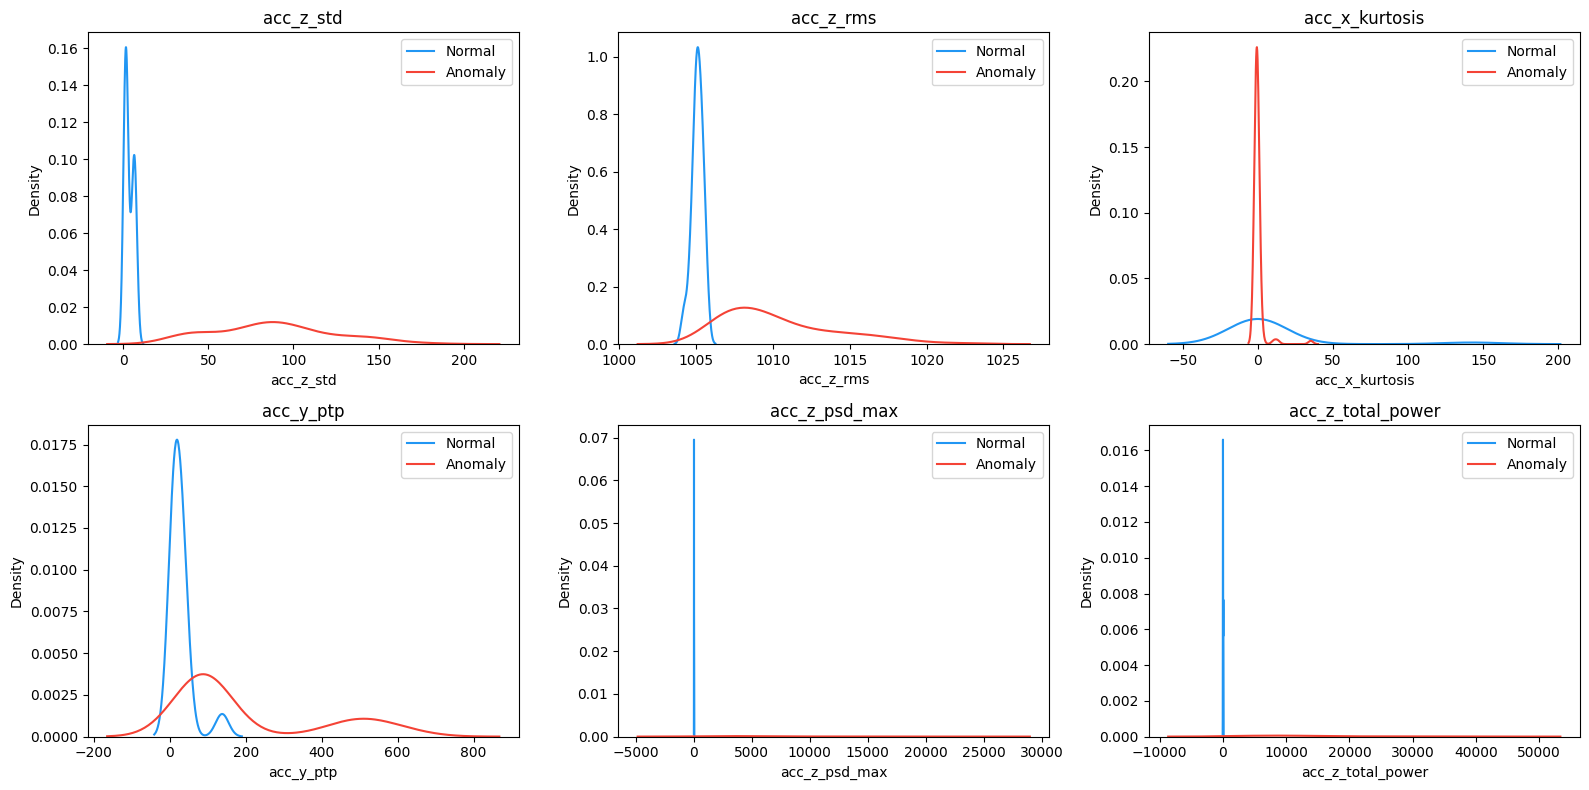

In [7]:
feat_columns = feature_names
normal_df = pd.DataFrame(normal_feat, columns=feat_columns)
anomaly_df = pd.DataFrame(anomaly_feat, columns=feat_columns)
normal_df["label"] = 0
anomaly_df["label"] = 1

top_features = ["acc_z_std", "acc_z_rms", "acc_x_kurtosis", "acc_y_ptp",
                "acc_z_psd_max", "acc_z_total_power"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for idx, feat in enumerate(top_features):
    if feat not in feat_columns:
        continue
    ax = axes[idx // 3, idx % 3]
    sns.kdeplot(normal_df[feat], ax=ax, label="Normal", color="#2196F3")
    sns.kdeplot(anomaly_df[feat], ax=ax, label="Anomaly", color="#F44336")
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/h1_feature_distribution.png", dpi=150)
plt.show()

### 8. 정규화 & 데이터 분할

두 가지 접근법에 맞게 각각 다른 전처리를 수행합니다.

#### 특징 기반 접근 (Isolation Forest)
- 42차원 특징 벡터에 대해 <span style="color:#2980B9">MinMaxScaler</span>로 전역 정규화
- <span style="color:#2980B9">stratify=y_all</span>: 정상/이상 비율을 학습/테스트에서 동일하게 유지

#### Autoencoder 접근
- <span style="color:#27AE60">(n, 2000, 3) → (n, 6000)</span>으로 평탄화
- <span style="color:#E74C3C; font-weight:bold">샘플별(per-sample) 정규화</span>: 각 윈도우를 독립적으로 [0,1] 범위로 변환합니다. 윈도우마다 진동 범위가 다를 수 있어 전역 정규화보다 안정적입니다

```{admonition} 핵심 원칙: 정상 데이터로만 학습!
:class: tip

Autoencoder는 **정상 데이터만**으로 학습합니다.
정상 패턴의 재구성만 학습하므로, 처음 보는 이상 패턴은 재구성을 잘 못합니다.
이 **재구성 오차의 차이**를 이용해 이상을 탐지하는 것이 Autoencoder 기반 이상탐지의 핵심 원리입니다.
```

In [8]:
# 특징 기반 접근용
X_all = np.vstack([normal_feat, anomaly_feat])
y_all = np.concatenate([np.zeros(len(normal_feat)), np.ones(len(anomaly_feat))])

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

scaler_feat = MinMaxScaler()
X_train_scaled = scaler_feat.fit_transform(X_train)
X_test_scaled  = scaler_feat.transform(X_test)

print(f"학습: {X_train_scaled.shape} (정상 {int((1-y_train).sum())}, 이상 {int(y_train.sum())})")
print(f"테스트: {X_test_scaled.shape} (정상 {int((1-y_test).sum())}, 이상 {int(y_test.sum())})")

# Autoencoder용 — 평탄화된 다운샘플링 데이터
normal_flat = normal_ds.reshape(normal_ds.shape[0], -1)    # (n, 2000*3)
anomaly_flat = anomaly_ds.reshape(anomaly_ds.shape[0], -1)
mixed_flat = mixed_ds.reshape(mixed_ds.shape[0], -1)


def normalize_per_sample(data):
    """샘플별 Min-Max 정규화."""
    min_v = data.min(axis=1, keepdims=True)
    max_v = data.max(axis=1, keepdims=True)
    return (data - min_v) / (max_v - min_v + 1e-11)


normal_norm   = normalize_per_sample(normal_flat)
anomaly_norm  = normalize_per_sample(anomaly_flat)
mixed_norm    = normalize_per_sample(mixed_flat)

# Autoencoder는 정상 데이터로만 학습
X_ae_train, X_ae_val = train_test_split(normal_norm, test_size=0.2, random_state=RANDOM_STATE)
print(f"AE 학습: {X_ae_train.shape}, AE 검증: {X_ae_val.shape}")


학습: (93, 42) (정상 14, 이상 79)
테스트: (24, 42) (정상 3, 이상 21)
AE 학습: (13, 6000), AE 검증: (4, 6000)


### 9. 이상탐지 — Isolation Forest

<span style="color:#E74C3C; font-weight:bold">Isolation Forest</span>는 결정 트리 기반 이상탐지 알고리즘입니다.

**핵심 원리**: 이상치는 특성 공간에서 **고립되기 쉽다**는 점을 이용합니다. 정상 데이터는 밀집된 클러스터를 형성하므로 많은 분할이 필요하지만, 이상치는 드문 영역에 위치해 적은 분할만으로 격리됩니다.

- <span style="color:#2980B9">n_estimators=200</span>: 앙상블 트리 개수 (많을수록 안정적)
- <span style="color:#2980B9">contamination=0.3</span>: 데이터의 30%가 이상일 것으로 가정
- 출력: <span style="color:#E74C3C; font-weight:bold">1=정상, -1=이상</span> (변환 필요)


In [9]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest.fit(X_train_scaled)

# predict()==-1 → 이상(True=1), 아니면 정상(False=0)
y_pred_iso = (iso_forest.predict(X_test_scaled) == -1).astype(int)

print("[Isolation Forest 결과]")
print(classification_report(y_test, y_pred_iso, target_names=["Normal", "Anomaly"]))


[Isolation Forest 결과]
              precision    recall  f1-score   support

      Normal       0.12      0.67      0.20         3
     Anomaly       0.86      0.29      0.43        21

    accuracy                           0.33        24
   macro avg       0.49      0.48      0.31        24
weighted avg       0.76      0.33      0.40        24



### 10. 이상탐지 — Autoencoder

Autoencoder는 입력을 그대로 출력으로 복원하는 **자기 지도 학습(self-supervised)** 모델입니다.

#### 아키텍처

```
인코더: 6000 → 512 → 128 → 64 → 32  (정보 압축)
잠재공간: 32차원 (bottleneck)
디코더: 32 → 64 → 128 → 512 → 6000  (정보 복원)
```

#### 왜 이상탐지에 유효한가?

<span style="color:#E74C3C; font-weight:bold">Bottleneck(잠재공간)</span>이 핵심입니다. 6000차원을 32차원으로 압축하는 과정에서, 모델은 **가장 중요한 패턴만** 인코딩하는 법을 배웁니다. 정상 데이터로만 학습했으므로:

- 정상 입력 → 잘 압축/복원 → **재구성 오차 작음**
- 이상 입력 → 압축 실패 → **재구성 오차 큼**

#### 설계 선택

- <span style="color:#2980B9">loss="mae"</span>: MSE보다 이상치에 덜 민감하여 안정적 학습
- <span style="color:#2980B9">Dropout(0.2)</span>: 과적합 방지
- <span style="color:#2980B9">최종 sigmoid</span>: 출력을 [0,1] 범위로 제한 (정규화된 입력과 매칭)


In [10]:
input_dim = X_ae_train.shape[1]  # 6000

input_layer = Input(shape=(input_dim,))
encoded = Dense(512, activation="relu")(input_layer)
encoded = Dropout(0.2)(encoded)
encoded = Dense(128, activation="relu")(encoded)
encoded = Dropout(0.2)(encoded)
encoded = Dense(64, activation="relu")(encoded)
encoded = Dense(32, activation="relu")(encoded)  # bottleneck

decoded = Dense(64, activation="relu")(encoded)
decoded = Dropout(0.2)(decoded)
decoded = Dense(128, activation="relu")(decoded)
decoded = Dropout(0.2)(decoded)
decoded = Dense(512, activation="relu")(decoded)
decoded = Dense(input_dim, activation="sigmoid")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=1e-4), loss="mae")
autoencoder.summary()


E0000 00:00:1780377728.282351 2463399 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,072,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6000)           │     3,078,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,302,992 (24.04 MB)

 Trainable params: 6,302,992 (24.04 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
EPOCHS = 50
BATCH_SIZE = 32

history = autoencoder.fit(
    X_ae_train, X_ae_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_ae_val, X_ae_val),
    shuffle=True,
    verbose=1
)


Epoch 1/50


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.4794

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.4794 - val_loss: 0.4877


Epoch 2/50


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - loss: 0.4787

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0198

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.0198 - val_loss: 0.0111


Epoch 50/50


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0200

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0200 - val_loss: 0.0111


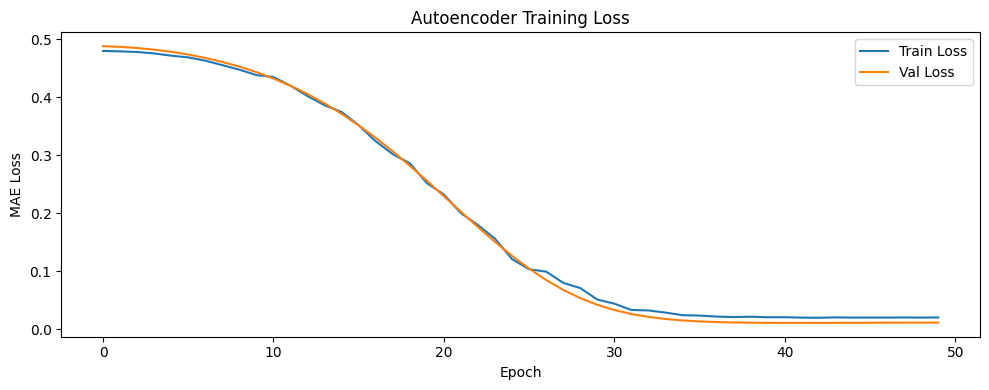

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MAE Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/h1_ae_training.png", dpi=150)
plt.show()

### 11. 임계값 설정 & 이상 판정

핵심 질문: **"재구성 오차가 얼마나 커야 이상으로 판정할까?"**

<span style="color:#E74C3C; font-weight:bold">IQR(사분위수 범위) 방법</span>으로 통계적 임계값을 산출합니다:

1. 정상 검증 데이터의 재구성 오차 분포를 분석
2. Q1(25%), Q3(75%) 계산 → IQR = Q3 - Q1
3. <span style="color:#E74C3C; font-weight:bold">upper_threshold = Q3 + 1.5 × IQR</span> (박스플롯 이상치 기준과 동일)

테스트 데이터는 **앞쪽 정상, 뒤쪽 이상**을 순차 배치하여 시각화에서 경계를 명확히 확인합니다.

```{admonition} 판정 로직
:class: tip

재구성 오차 > 임계값 → **이상!**
정상 데이터는 학습했으므로 잘 재구성 → 오차 작음
이상 데이터는 처음 보는 패턴 → 재구성 실패 → 오차 큼
```

Q1=0.008104, Q3=0.011670, IQR=0.003566
이상탐지 임계값 (상한): 0.017018


/tmp/ipykernel_2463399/283383041.py:19: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/283383041.py:19: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/283383041.py:19: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/283383041.py:19: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/283383041.py:19: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/283383041.py:19: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/283383041.py:19: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  

/home/growingwithai/dev/205-research-etri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/growingwithai/dev/205-research-etri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/growingwithai/dev/205-research-etri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/growingwithai/dev/205-research-etri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/growingwithai/dev/205-research-etri/.venv/lib/pytho

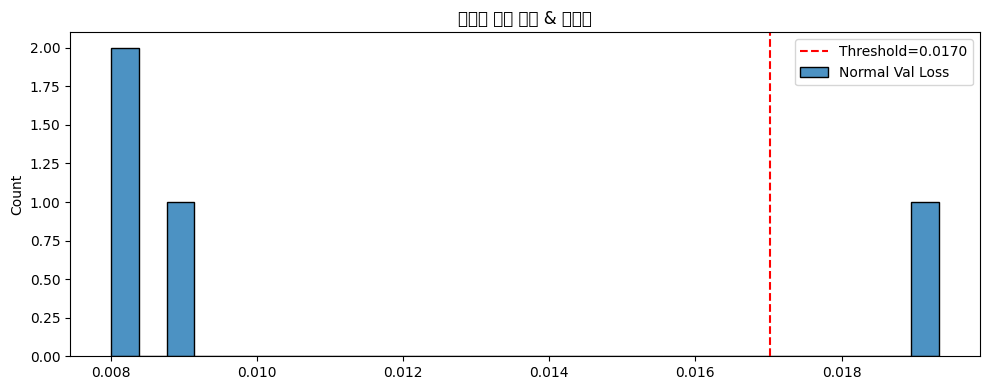

In [13]:
# 검증 데이터로 임계값 산출
val_pred = autoencoder.predict(X_ae_val, verbose=0)
val_loss = tf.keras.losses.mae(val_pred, X_ae_val).numpy()

Q1 = np.quantile(val_loss, 0.25)
Q3 = np.quantile(val_loss, 0.75)
IQR = Q3 - Q1
upper_threshold = Q3 + 1.5 * IQR

print(f"Q1={Q1:.6f}, Q3={Q3:.6f}, IQR={IQR:.6f}")
print(f"이상탐지 임계값 (상한): {upper_threshold:.6f}")

# 임계값 분포 시각화
plt.figure(figsize=(10, 4))
sns.histplot(val_loss, bins=30, alpha=0.8, label="Normal Val Loss")
plt.axvline(x=upper_threshold, color="red", linestyle="--", label=f"Threshold={upper_threshold:.4f}")
plt.title("재구성 오차 분포 & 임계값")
plt.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/h1_threshold.png", dpi=150)
plt.show()

[Autoencoder 결과]
              precision    recall  f1-score   support

      Normal       1.00      0.65      0.79        17
     Anomaly       0.94      1.00      0.97       100

    accuracy                           0.95       117
   macro avg       0.97      0.82      0.88       117
weighted avg       0.95      0.95      0.94       117



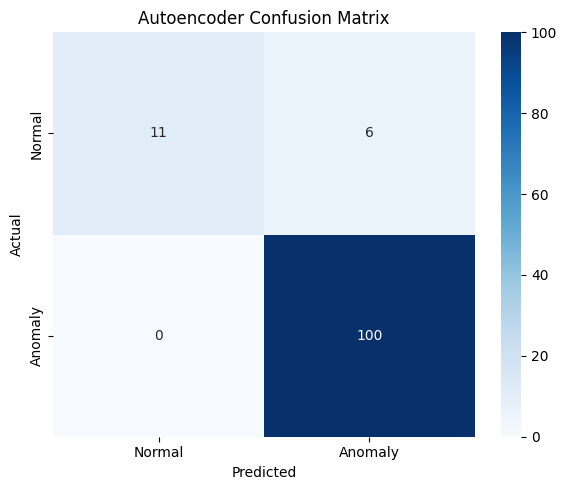

In [14]:
# 테스트 구성: 앞쪽 정상, 뒤쪽 이상
test_all_norm = np.vstack([normalize_per_sample(normal_flat), anomaly_norm])
test_labels = np.concatenate([np.zeros(len(normal_flat)), np.ones(len(anomaly_flat))])

test_pred = autoencoder.predict(test_all_norm, verbose=0)
test_loss = tf.keras.losses.mae(test_pred, test_all_norm).numpy()

ae_pred = (test_loss > upper_threshold).astype(int)

print("[Autoencoder 결과]")
print(classification_report(test_labels, ae_pred, target_names=["Normal", "Anomaly"]))

cm = confusion_matrix(test_labels, ae_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Autoencoder Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/h1_confusion_matrix.png", dpi=150)
plt.show()

### 12. 재구성 오차 시각화

아래 플롯에서:

- **왼쪽** (초록 점선 이전): 정상 데이터의 재구성 오차 — 대체로 임계값(빨간 점선) 이하
- **오른쪽** (초록 점선 이후): 이상 데이터의 재구성 오차 — 임계값을 크게 상회하는 경향
- 오차가 <span style="color:#E74C3C; font-weight:bold">임계값(빨간 점선)을 넘으면 이상</span>으로 판정합니다


/tmp/ipykernel_2463399/2401206311.py:9: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/2401206311.py:9: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/2401206311.py:9: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/2401206311.py:9: UserWarning: Glyph 45937 (\N{HANGUL SYLLABLE DEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/2401206311.py:9: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/2401206311.py:9: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2463399/2401206311.py:9: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.

/home/growingwithai/dev/205-research-etri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/growingwithai/dev/205-research-etri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/growingwithai/dev/205-research-etri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/growingwithai/dev/205-research-etri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/growingwithai/dev/205-research-etri/.venv/lib/pytho

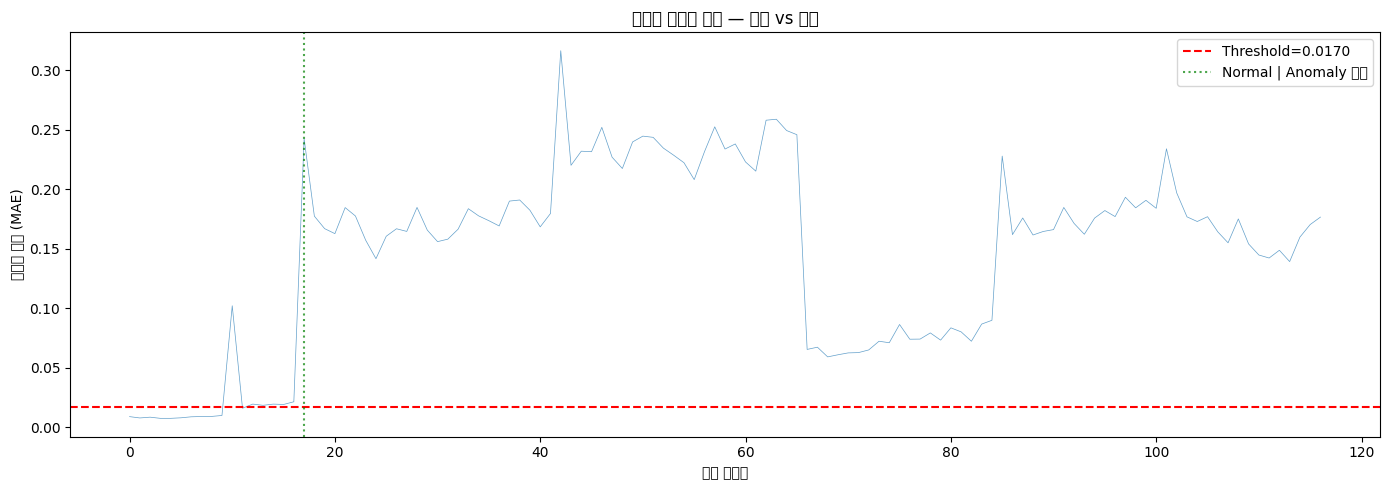

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(test_loss, alpha=0.7, linewidth=0.5)
plt.axhline(y=upper_threshold, color="red", linestyle="--", label=f"Threshold={upper_threshold:.4f}")
plt.axvline(x=len(normal_flat), color="green", linestyle=":", alpha=0.7, label="Normal | Anomaly 경계")
plt.xlabel("샘플 인덱스")
plt.ylabel("재구성 오차 (MAE)")
plt.title("샘플별 재구성 오차 — 정상 vs 이상")
plt.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/h1_reconstruction_error.png", dpi=150)
plt.show()

### 13. 결과 요약

두 이상탐지 방법의 **Weighted F1 Score**를 비교합니다.

| 방법 | 접근 | 학습 데이터 | 장점 |
|------|------|-------------|------|
| Isolation Forest | 특징 기반 | 정상 + 이상 | 빠르고 해석 용이 |
| Autoencoder | 재구성 오차 | 정상만 | 라벨 불필요, 복잡 패턴 학습 |


In [16]:
iso_f1 = f1_score(y_test, y_pred_iso, average="weighted")
ae_f1  = f1_score(test_labels, ae_pred, average="weighted")

print(f"Isolation Forest F1 (weighted): {iso_f1:.4f}")
print(f"Autoencoder     F1 (weighted): {ae_f1:.4f}")
print(f"\n생성된 시각화 파일:")
for f in sorted(glob(f"{SAVE_DIR}/h1_*.png")):
    print(f"  - {f}")

Isolation Forest F1 (weighted): 0.4000
Autoencoder     F1 (weighted): 0.9440

생성된 시각화 파일:
  - /home/growingwithai/dev/205-research-etri/lecture/h1_ae_training.png
  - /home/growingwithai/dev/205-research-etri/lecture/h1_confusion_matrix.png
  - /home/growingwithai/dev/205-research-etri/lecture/h1_eda_distribution.png
  - /home/growingwithai/dev/205-research-etri/lecture/h1_eda_raw.png
  - /home/growingwithai/dev/205-research-etri/lecture/h1_feature_distribution.png
  - /home/growingwithai/dev/205-research-etri/lecture/h1_reconstruction_error.png
  - /home/growingwithai/dev/205-research-etri/lecture/h1_threshold.png
